# Lecture 20-22: Image Segmentation & Object Detection + Denoising

**Segmentation (1~4)**
1. K-means clustering
2. SLIC Superpixels
3. Graph Cuts
4. UNet (Deep Learning)

**Object Detection (5~8)**

5. Template Matching
6. Shi-Tomasi Corner Detector
7. RCNN (pretrained Faster R-CNN)
8. CLIP (Zero-shot Classification)

**Denoising (9~10)**

9. Box function
10. Gaussian

In [ ]:
import torch

# GPU 인식 여부 및 정보 출력
is_cuda = torch.cuda.is_available()
print(f"GPU 사용 가능 여부: {is_cuda}")

if is_cuda:
    print(f"사용 중인 GPU: {torch.cuda.get_device_name(0)}")
else:
    print("현재 CPU를 사용 중입니다. GPU를 사용하려면 '런타임 > 런타임 유형 변경'에서 GPU를 선택해 주세요.")

In [ ]:
# Run this codeblock to mount your Google Drive in Google Colab.
from google.colab import drive

drive.mount("/content/drive/")

In [ ]:
# 필요한 패키지 설치
!pip install -q torch torchvision
!pip install -q opencv-python scikit-image scikit-learn
!pip install -q open_clip_torch

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF

import cv2
from skimage.segmentation import slic, mark_boundaries
from sklearn.cluster import KMeans

# 재현성을 위한 seed 설정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
ROOT = "/content/drive/MyDrive/실습10"  # TODO: set your root directory here

ROOT = Path(ROOT)
ROOT.mkdir(parents=True, exist_ok=True)

print(f"Check GPU availability: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Segmentation

## 0. Dataset 준비 (Oxford-IIIT Pet Dataset)

Oxford pet dataset은 37종의 반려동물 이미지와 그에 대한 segmentation mask(trimap)를 제공합니다.

**Trimap label 정의**
- 1 → foreground (pet)
- 2 → background
- 3 → not classified (border)


In [ ]:
# ====== 사용자 파라미터 ======
TRAIN_DATA_RATIO = 0.3   # 0.3 = 30%, 1.0 = 전체 사용
IMG_SIZE = 128           # UNet input size
BATCH_SIZE = 16
# ============================


class OxfordPetDataset(Dataset):
    """Oxford-IIIT Pet Dataset wrapper.

    - image: float tensor, shape (3, H, W), [0, 1] range
    - mask:  long tensor,  shape (H, W),    values {0: pet, 1: bg, 2: border}
    """

    def __init__(self, root, split="trainval", img_size=IMG_SIZE):
        self.dataset = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True,
        )
        self.img_size = img_size
        self.image_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size),
                              interpolation=transforms.InterpolationMode.NEAREST),
            transforms.PILToTensor(),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]
        img = self.image_transform(img)                                # (3, H, W) float
        mask = self.mask_transform(mask).long().squeeze(0) - 1         # 1,2,3 -> 0,1,2
        return img, mask


In [ ]:
# Train / Test set 다운로드 및 생성
full_trainset = OxfordPetDataset(ROOT / "data", split="trainval")
full_testset = OxfordPetDataset(ROOT / "data", split="test")

print(f"Full train set size: {len(full_trainset)}")
print(f"Full test  set size: {len(full_testset)}")

# 학습 데이터의 일부만 사용 (TRAIN_DATA_RATIO)
n_train = int(len(full_trainset) * TRAIN_DATA_RATIO)
np.random.seed(SEED)
indices = np.random.permutation(len(full_trainset))[:n_train]
trainset = Subset(full_trainset, indices.tolist())
print(f"Subset train size ({TRAIN_DATA_RATIO * 100:.0f}%): {len(trainset)}")

train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(full_testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [ ]:
SAMPLE_IDX = 7   # 비교에 사용할 test sample의 index

# (1) raw PIL 이미지 / mask  ----- conventional methods (k-means, SLIC, graph cut)에 사용
sample_img_pil, sample_mask_pil = full_testset.dataset[SAMPLE_IDX]
sample_img_np = np.array(sample_img_pil)         # (H, W, 3), uint8
sample_mask_np = np.array(sample_mask_pil)        # (H, W), values in {1, 2, 3}

# (2) tensor 형태의 동일 sample  ----- UNet에 사용
sample_img_tensor, sample_mask_tensor = full_testset[SAMPLE_IDX]

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_img_np)
axes[0].set_title("Sample Image")
axes[0].axis("off")
axes[1].imshow(sample_mask_np, cmap="viridis")
axes[1].set_title("Ground-truth Trimap (1=pet, 2=bg, 3=border)")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 1. K-means Clustering Segmentation

각 픽셀을 색상 (혹은 색상 + 위치) 5D 벡터로 보고 k개의 cluster로 군집화합니다.

$$
x_i \in \text{cluster } j \;\;\text{if}\;\; \|x_i - m_j\| < \|x_i - m_k\|, \;\; k \neq j
$$

$$
m_j = \frac{1}{|C_j|} \sum_{x \in C_j} x
$$

In [ ]:
def kmeans_segmentation(img, k=2, use_xy=False, seed=SEED):
    """Pixel-wise K-means clustering.

    Args:
        img:     (H, W, 3) uint8 RGB image
        k:       number of clusters
    Returns:
        labels:  (H, W) int array of cluster ids
    """
    h, w = img.shape[:2]
    features = img.reshape(-1, 3).astype(np.float32)
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(features)
    return labels.reshape(h, w)

kmeans_rgb = kmeans_segmentation(sample_img_np, k=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_img_np);             axes[0].set_title("Original");          axes[0].axis("off")
axes[1].imshow(kmeans_rgb, cmap="viridis"); axes[1].set_title("K-means (RGB, k=2)"); axes[1].axis("off")
axes[2].imshow(sample_mask_np, cmap="viridis"); axes[2].set_title("Ground Truth"); axes[2].axis("off")
plt.tight_layout()
plt.show()


## 2. SLIC Superpixels

SLIC는 K-means의 변형으로, 5D vector $[r, g, b, x, y]$로 클러스터링하지만
연결성과 위치를 강하게 유지하도록 설계된 알고리즘입니다.

거리 함수:

$$
D = \sqrt{\left(\frac{d_c}{c}\right)^2 + \left(\frac{d_s}{s}\right)^2}
$$

* `c` (compactness)가 클수록 더 색상 중심 cluster
* `c`가 작을수록 더 공간적 경계에 잘 달라붙음


In [ ]:
# 다양한 superpixel 개수로 실험
n_segments_list = [1000, 500, 250]

fig, axes = plt.subplots(2, len(n_segments_list) + 1, figsize=(5 * (len(n_segments_list) + 1), 10))

axes[0, 0].imshow(sample_img_np); axes[0, 0].set_title("Original"); axes[0, 0].axis("off")
axes[1, 0].axis("off")

for i, n_seg in enumerate(n_segments_list):
    superpixels = slic(sample_img_np, n_segments=n_seg,
                       compactness=10, sigma=1, start_label=1)
    boundaries = mark_boundaries(sample_img_np, superpixels, color=(1, 1, 0))

    # 평균 색으로 채운 superpixel 시각화
    avg_img = np.zeros_like(sample_img_np, dtype=np.float32)
    for sid in np.unique(superpixels):
        mask = superpixels == sid
        avg_img[mask] = sample_img_np[mask].mean(axis=0)

    axes[0, i + 1].imshow(boundaries)
    axes[0, i + 1].set_title(f"SLIC boundary ({n_seg})")
    axes[0, i + 1].axis("off")

    axes[1, i + 1].imshow(avg_img.astype(np.uint8))
    axes[1, i + 1].set_title(f"SLIC mean color ({n_seg})")
    axes[1, i + 1].axis("off")

plt.tight_layout()
plt.show()


## 3. Graph Cuts Segmentation

Graph cut은 픽셀들을 노드로, foreground / background를 두 개의 terminal로 보고
**최소 cut을 찾아 fg/bg를 분리**하는 방법입니다.

OpenCV의 `grabCut`은 graph cut + GMM 기반의 알고리즘으로, 강의에서 다룬 Graph cuts segmentation의 실제 구현체로 사용할 수 있습니다.


In [ ]:
def graphcut_segmentation(img, num_iter=5):
    """Graph Cuts segmentation with automatic FG/BG seeds.

    Center region    -> Definite foreground (GC_FGD)
    Border region    -> Definite background (GC_BGD)
    Surrounding area -> Probable foreground (GC_PR_FGD)
    The rest         -> Probable background (GC_PR_BGD)
    """
    h, w = img.shape[:2]
    mask = np.full((h, w), cv2.GC_PR_BGD, dtype=np.uint8)

    # 가장자리: 확실한 배경
    border = max(1, min(h, w) // 8)
    mask[:border, :] = cv2.GC_BGD
    mask[-border:, :] = cv2.GC_BGD
    mask[:, :border] = cv2.GC_BGD
    mask[:, -border:] = cv2.GC_BGD

    # 중앙 사각형 주변: 가능성있는 전경
    cy, cx = h // 2, w // 2
    pr_fg = min(h, w) // 3
    mask[max(0, cy - pr_fg):cy + pr_fg, max(0, cx - pr_fg):cx + pr_fg] = cv2.GC_PR_FGD

    # 중앙: 확실한 전경
    fg = min(h, w) // 8
    mask[max(0, cy - fg):cy + fg, max(0, cx - fg):cx + fg] = cv2.GC_FGD

    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    # OpenCV는 BGR을 사용
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    seeds = mask.copy()
    cv2.grabCut(img_bgr, mask, None, bgd_model, fgd_model,
                num_iter, cv2.GC_INIT_WITH_MASK)

    # 결과: foreground=1, background=0
    result = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)
    return result, seeds


# 동일 sample에 대해 graph cuts 적용
gc_result, gc_seeds = graphcut_segmentation(sample_img_np, num_iter=5)

# Seed 시각화
seed_vis = sample_img_np.copy()
seed_vis[gc_seeds == cv2.GC_BGD] = [30, 30, 200]      # 진한 파랑 = 확실한 배경
seed_vis[gc_seeds == cv2.GC_PR_BGD] = [120, 120, 200] # 옅은 파랑 = 가능성있는 배경
seed_vis[gc_seeds == cv2.GC_PR_FGD] = [200, 120, 120] # 옅은 빨강 = 가능성있는 전경
seed_vis[gc_seeds == cv2.GC_FGD] = [200, 30, 30]      # 진한 빨강 = 확실한 전경

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(sample_img_np); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(seed_vis); axes[1].set_title("Seeds (red=FG, blue=BG)"); axes[1].axis("off")
axes[2].imshow(gc_result, cmap="viridis"); axes[2].set_title("Graph Cuts result"); axes[2].axis("off")
axes[3].imshow((sample_mask_np == 1).astype(np.uint8), cmap="viridis")
axes[3].set_title("GT (foreground only)")
axes[3].axis("off")
plt.tight_layout()
plt.show()


## 4. UNet Segmentation (Deep Learning)

UNet은 encoder-decoder 구조에 **skip connection**을 추가하여,
decoder가 upsampling할 때 encoder의 high-resolution feature를 함께 사용할 수 있게 한 네트워크입니다.

여기서는 3-class segmentation (pet / background / border)을 학습시킵니다.


In [ ]:
class DoubleConv(nn.Module):
    """(Conv → BN → ReLU) × 2."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    """UNet (Ronneberger et al., MICCAI 2015) - simplified version."""

    def __init__(self, n_channels=3, n_classes=3, base_ch=32):
        super().__init__()

        # ----- Encoder (contracting path) -----
        self.enc1 = DoubleConv(n_channels, base_ch)
        self.enc2 = DoubleConv(base_ch,    base_ch * 2)
        self.enc3 = DoubleConv(base_ch * 2, base_ch * 4)
        self.enc4 = DoubleConv(base_ch * 4, base_ch * 8)

        # ----- Bottleneck -----
        self.bottleneck = DoubleConv(base_ch * 8, base_ch * 16)

        # ----- Decoder (expansive path) -----
        self.up4 = nn.ConvTranspose2d(base_ch * 16, base_ch * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_ch * 16, base_ch * 8)
        self.up3 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_ch * 8, base_ch * 4)
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_ch * 4, base_ch * 2)
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_ch * 2, base_ch)

        self.out_conv = nn.Conv2d(base_ch, n_classes, kernel_size=1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder with skip connections
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out_conv(d1)


# 모델 instantiation 및 파라미터 수 확인
unet_model = UNet(n_channels=3, n_classes=3, base_ch=32).to(device)
n_params = sum(p.numel() for p in unet_model.parameters() if p.requires_grad)
print(f"UNet trainable parameters: {n_params:,}")


In [ ]:
import torch
from pathlib import Path
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training will use device: {device}")

# Ensure ROOT and parameters are defined
ROOT = Path("/content/drive/MyDrive/실습_예비")
ROOT.mkdir(parents=True, exist_ok=True)
TRAIN_DATA_RATIO = 0.3
IMG_SIZE = 128
BATCH_SIZE = 16
SEED = 42

# Redefine Dataset Class for self-containment
class OxfordPetDataset(Dataset):
    def __init__(self, root, split="trainval", img_size=IMG_SIZE):
        self.dataset = datasets.OxfordIIITPet(root=root, split=split, target_types="segmentation", download=True)
        self.img_size = img_size
        self.image_transform = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ToTensor()])
        self.mask_transform = transforms.Compose([transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.NEAREST), transforms.PILToTensor()])
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        img, mask = self.dataset[idx]
        img = self.image_transform(img)
        mask = self.mask_transform(mask).long().squeeze(0) - 1
        return img, mask

# Ensure train_loader exists
if 'train_loader' not in globals():
    print("Re-initializing data loaders...")
    full_trainset = OxfordPetDataset(ROOT / "data", split="trainval")
    n_train = int(len(full_trainset) * TRAIN_DATA_RATIO)
    np.random.seed(SEED)
    indices = np.random.permutation(len(full_trainset))[:n_train]
    trainset = Subset(full_trainset, indices.tolist())
    train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# Define Model Classes
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=3, base_ch=32):
        super().__init__()
        self.enc1, self.enc2, self.enc3, self.enc4 = DoubleConv(3, 32), DoubleConv(32, 64), DoubleConv(64, 128), DoubleConv(128, 256)
        self.bottleneck = DoubleConv(256, 512)
        self.up4, self.dec4 = nn.ConvTranspose2d(512, 256, 2, 2), DoubleConv(512, 256)
        self.up3, self.dec3 = nn.ConvTranspose2d(256, 128, 2, 2), DoubleConv(256, 128)
        self.up2, self.dec2 = nn.ConvTranspose2d(128, 64, 2, 2), DoubleConv(128, 64)
        self.up1, self.dec1 = nn.ConvTranspose2d(64, 32, 2, 2), DoubleConv(64, 32)
        self.out_conv = nn.Conv2d(32, 3, 1)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2)); e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], 1)); d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1)); d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.out_conv(d1)

if 'unet_model' not in globals():
    unet_model = UNet().to(device)

# ====== UNet 학습 ======
EPOCHS, LR = 30, 1e-3
UNET_CKPT = ROOT / "unet_best.pth"
unet_optimizer = torch.optim.Adam(unet_model.parameters(), lr=LR)
unet_criterion = nn.CrossEntropyLoss()

train_loss_history = []
print(f"Training UNet on {device}...")
for epoch in range(EPOCHS):
    unet_model.train()
    total_loss = 0.0
    for img, mask in train_loader:
        img, mask = img.to(device), mask.to(device)
        unet_optimizer.zero_grad()
        loss = unet_criterion(unet_model(img), mask)
        loss.backward(); unet_optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_loss_history.append(avg_loss)
    print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss:.4f}")

torch.save(unet_model.state_dict(), UNET_CKPT)
plt.figure(figsize=(8, 4)); plt.plot(range(1, EPOCHS + 1), train_loss_history, marker="o"); plt.title("UNet Training Loss"); plt.show()

In [ ]:
# ====== 동일한 sample에 대해 UNet inference ======
unet_model.eval()
with torch.no_grad():
    pred = unet_model(sample_img_tensor.unsqueeze(0).to(device))
    pred_mask = pred.argmax(dim=1).squeeze(0).cpu().numpy()    # (H, W) ∈ {0,1,2}

# UNet은 IMG_SIZE × IMG_SIZE에서 학습/예측되므로 GT도 동일 크기로 resize하여 비교
sample_img_resized = np.array(sample_img_pil.resize((IMG_SIZE, IMG_SIZE)))
sample_mask_resized = np.array(
    sample_mask_pil.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
) - 1   # 1,2,3 → 0,1,2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_img_resized);                      axes[0].set_title("Image (resized)"); axes[0].axis("off")
axes[1].imshow(sample_mask_resized, cmap="viridis", vmin=0, vmax=2)
axes[1].set_title("Ground Truth"); axes[1].axis("off")
axes[2].imshow(pred_mask, cmap="viridis", vmin=0, vmax=2)
axes[2].set_title("UNet Prediction"); axes[2].axis("off")
plt.tight_layout()
plt.show()


### Segmentation 방법 종합 비교

동일한 image에 대해 4가지 segmentation 방법을 한눈에 비교합니다.
- Conventional 방법(K-means, SLIC, Graph cuts)은 **학습 없이** 동작
- UNet은 학습된 모델


In [ ]:
# IoU score 계산 함수 - foreground 영역에 대해서만
def compute_iou(pred_fg, gt_fg):
    """Binary IoU between two boolean masks."""
    intersection = np.logical_and(pred_fg, gt_fg).sum()
    union = np.logical_or(pred_fg, gt_fg).sum()
    return intersection / union if union > 0 else 0.0


# 비교를 위해 모두 같은 크기로 맞춤 (UNet 결과 기준 IMG_SIZE × IMG_SIZE)
sample_img_low = np.array(sample_img_pil.resize((IMG_SIZE, IMG_SIZE)))
gt_fg_low = (np.array(sample_mask_pil.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)) == 1)

# 각 결과를 IMG_SIZE 크기로 다시 계산
kmeans_low = kmeans_segmentation(sample_img_low, k=2, use_xy=True)
gc_result_low, _ = graphcut_segmentation(sample_img_low, num_iter=5)

# K-means에서 가장 GT와 일치하는 cluster를 foreground로 자동 매칭
def best_kmeans_fg(labels, gt):
    best_iou = -1
    best_id = 0
    for cid in np.unique(labels):
        iou = compute_iou(labels == cid, gt)
        if iou > best_iou:
            best_iou = iou
            best_id = cid
    return labels == best_id, best_iou


kmeans_fg_low, _ = best_kmeans_fg(kmeans_low, gt_fg_low)
unet_fg_low = (pred_mask == 0)   # class 0 = pet

iou_kmeans = compute_iou(kmeans_fg_low, gt_fg_low)
iou_gc = compute_iou(gc_result_low.astype(bool), gt_fg_low)
iou_unet = compute_iou(unet_fg_low, gt_fg_low)

print(f"K-means (best-matched cluster) IoU: {iou_kmeans:.3f}")
print(f"Graph Cuts                     IoU: {iou_gc:.3f}")
print(f"UNet                           IoU: {iou_unet:.3f}")

# 종합 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(sample_img_low); axes[0, 0].set_title("Original Image"); axes[0, 0].axis("off")
axes[0, 1].imshow(kmeans_fg_low, cmap="gray"); axes[0, 1].set_title(f"K-means (IoU={iou_kmeans:.3f})"); axes[0, 1].axis("off")
axes[0, 2].imshow(slic(sample_img_low, n_segments=250, compactness=10, sigma=1, start_label=1), cmap="tab20")
axes[0, 2].set_title("SLIC Superpixels (250)"); axes[0, 2].axis("off")

axes[1, 0].imshow(gc_result_low, cmap="gray"); axes[1, 0].set_title(f"Graph Cuts (IoU={iou_gc:.3f})"); axes[1, 0].axis("off")
axes[1, 1].imshow(unet_fg_low, cmap="gray"); axes[1, 1].set_title(f"UNet (IoU={iou_unet:.3f})"); axes[1, 1].axis("off")
axes[1, 2].imshow(gt_fg_low, cmap="gray"); axes[1, 2].set_title("Ground Truth (foreground)"); axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


# Object detection

## 6. Shi-Tomasi Corner Detector

각 픽셀에서 gradient를 계산해 다음 행렬을 만듭니다.

$$
M = \begin{bmatrix} \sum g_x^2 & \sum g_x g_y \\ \sum g_x g_y & \sum g_y^2 \end{bmatrix}
$$

이 $2 \times 2$ 행렬의 두 eigenvalue $\lambda_1, \lambda_2$가 모두 threshold 이상이면 corner로 간주합니다.
OpenCV의 `cv2.goodFeaturesToTrack`이 이 알고리즘을 구현하고 있습니다.


In [ ]:
def shi_tomasi(img, max_corners=200, quality_level=0.01, min_distance=10):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    corners = cv2.goodFeaturesToTrack(
        gray,
        maxCorners=max_corners,
        qualityLevel=quality_level,
        minDistance=min_distance,
    )
    return corners.reshape(-1, 2) if corners is not None else np.empty((0, 2))


# 동일 sample에 대해 여러 quality level로 비교
quality_levels = [0.001, 0.01, 0.1]

fig, axes = plt.subplots(1, len(quality_levels), figsize=(5 * len(quality_levels), 5))
for ax, q in zip(axes, quality_levels):
    corners = shi_tomasi(sample_img_np, max_corners=300, quality_level=q, min_distance=5)
    img_vis = sample_img_np.copy()
    for x, y in corners:
        cv2.circle(img_vis, (int(x), int(y)), 3, (255, 0, 0), -1)
    ax.imshow(img_vis)
    ax.set_title(f"Shi-Tomasi (qualityLevel={q})\n{len(corners)} corners")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 7. R-CNN 계열: Faster R-CNN (pretrained)

R-CNN은 이미지에서 region proposal을 추출 → 각 proposal을 CNN으로 feature 추출 → SVM/regressor로 분류 및 bbox regression을 수행합니다.

원형 R-CNN은 너무 느려서 Fast R-CNN, Faster R-CNN으로 발전했습니다.
여기서는 **torchvision이 제공하는 pretrained Faster R-CNN** (COCO dataset으로 학습)을 활용해 sample image에서 객체를 검출합니다.


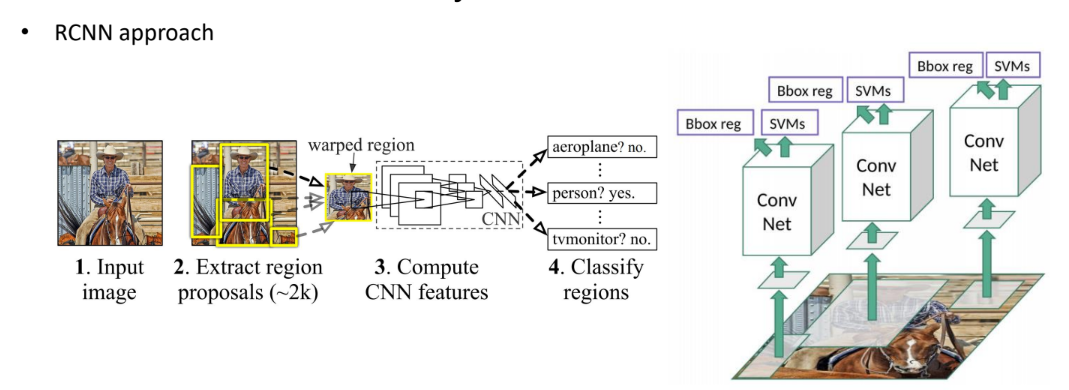

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
rcnn_model = fasterrcnn_resnet50_fpn(weights=weights).to(device)
rcnn_model.eval()

# COCO category 이름
coco_categories = weights.meta["categories"]
print(f"Number of COCO categories: {len(coco_categories)}")
print(f"Examples: {coco_categories[1:11]}")


In [ ]:
def detect_objects(model, img_pil, score_threshold=0.5):
    """Run Faster R-CNN on a PIL image."""
    img_tensor = TF.to_tensor(img_pil).to(device)

    with torch.no_grad():
        outputs = model([img_tensor])

    out = outputs[0]
    keep = out["scores"] >= score_threshold
    boxes = out["boxes"][keep].cpu().numpy()
    labels = out["labels"][keep].cpu().numpy()
    scores = out["scores"][keep].cpu().numpy()
    return boxes, labels, scores


def draw_boxes(img_np, boxes, labels, scores, categories):
    img_vis = img_np.copy()
    for box, label, sc in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        text = f"{categories[label]}: {sc:.2f}"
        cv2.putText(img_vis, text, (x1, max(y1 - 5, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return img_vis


# 동일 sample에 대해 detection
boxes, labels, scores = detect_objects(rcnn_model, sample_img_pil, score_threshold=0.5)
print(f"Detected {len(boxes)} objects above threshold 0.5")
for lbl, sc in zip(labels, scores):
    print(f"  - {coco_categories[lbl]} (score={sc:.3f})")

# 추가 sample 두 개에 대해서도 확인
extra_indices = [(SAMPLE_IDX + 30) % len(full_testset),
                 (SAMPLE_IDX + 100) % len(full_testset)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
img_vis_main = draw_boxes(sample_img_np, boxes, labels, scores, coco_categories)
axes[0].imshow(img_vis_main); axes[0].set_title(f"Sample #{SAMPLE_IDX}"); axes[0].axis("off")

for ax, idx in zip(axes[1:], extra_indices):
    other_pil, _ = full_testset.dataset[idx]
    other_np = np.array(other_pil)
    bx, lb, sc = detect_objects(rcnn_model, other_pil, score_threshold=0.5)
    ax.imshow(draw_boxes(other_np, bx, lb, sc, coco_categories))
    ax.set_title(f"Sample #{idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 8. CLIP (Contrastive Language-Image Pre-training)

CLIP은 image encoder와 text encoder를 contrastive learning으로 함께 학습시킨 모델입니다.

* image encoder: 이미지 → feature vector
* text encoder: 자연어 caption → feature vector
* 두 vector의 cosine similarity가 클수록 이미지와 caption이 잘 매칭됨

이 구조를 이용하면 별도의 학습 없이 임의의 class 이름을 prompt로 넣어 **zero-shot classification**을 할 수 있습니다.

여기서는 [`open_clip`](https://github.com/mlfoundations/open_clip)이 제공하는 pretrained ViT-B-32 모델(OpenAI weight)을 사용합니다.


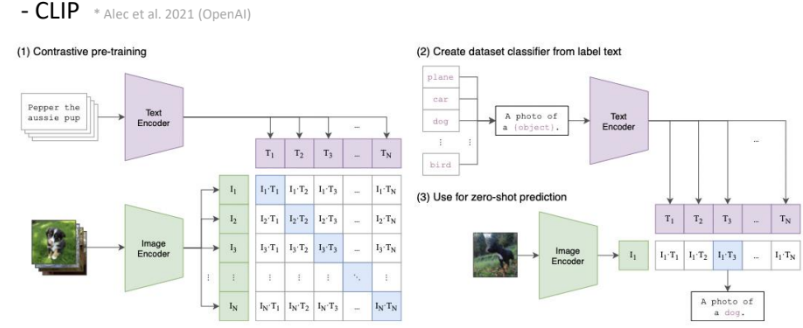

In [ ]:
import open_clip

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_model = clip_model.to(device).eval()
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")
print("CLIP model loaded.")


In [ ]:
def clip_zero_shot(model, preprocess, tokenizer, img_pil, class_names, template="a photo of a {}"):
    """Zero-shot classification with CLIP."""
    # 이미지 encoding
    img_input = preprocess(img_pil).unsqueeze(0).to(device)

    # 텍스트 encoding
    prompts = [template.format(name) for name in class_names]
    text_inputs = tokenizer(prompts).to(device)

    with torch.no_grad():
        img_feat = model.encode_image(img_input)
        txt_feat = model.encode_text(text_inputs)

        # normalize and cosine similarity
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

        # softmax probability
        logits = (100.0 * img_feat @ txt_feat.T)
        probs = logits.softmax(dim=-1).cpu().numpy().squeeze(0)

    return probs


# Oxford Pet 데이터셋이 가진 37개 breed 이름 가져오기
breed_classes = full_testset.dataset.classes
print(f"Number of breeds: {len(breed_classes)}")
print(f"Examples: {breed_classes[:5]}")

# 동일 sample에 대해 zero-shot classification
probs = clip_zero_shot(clip_model, clip_preprocess, clip_tokenizer,
                        sample_img_pil, breed_classes,
                        template="a photo of a {}, a type of pet")

# Top-5 출력
top5_idx = probs.argsort()[-5:][::-1]
print("\n=== CLIP zero-shot top-5 predictions ===")
for i, idx in enumerate(top5_idx):
    print(f"  {i + 1}. {breed_classes[idx]:30s}  prob={probs[idx]:.4f}")

# 실제 ground-truth breed 확인
_, sample_label = full_testset.dataset[SAMPLE_IDX]
# Note: target_types='segmentation' 이므로 raw class label은 별도로 가져와야 함
gt_dataset = datasets.OxfordIIITPet(root=ROOT / "data", split="test",
                                     target_types="category", download=False)
gt_label = gt_dataset[SAMPLE_IDX][1]
print(f"\nGround truth: {breed_classes[gt_label]}")


In [ ]:
# CLIP 결과 시각화 (sample image + top-5 probability bar chart)
fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                          gridspec_kw={"width_ratios": [1, 1.5]})

axes[0].imshow(sample_img_np)
axes[0].set_title(f"Input (GT: {breed_classes[gt_label]})")
axes[0].axis("off")

top5 = probs.argsort()[-5:][::-1]
top5_names = [breed_classes[i] for i in top5]
top5_probs = probs[top5]

bars = axes[1].barh(range(5), top5_probs[::-1], color="steelblue")
axes[1].set_yticks(range(5))
axes[1].set_yticklabels(top5_names[::-1])
axes[1].set_xlabel("Probability")
axes[1].set_title("CLIP zero-shot top-5")
axes[1].set_xlim([0, max(top5_probs.max() * 1.1, 0.1)])
for i, (b, p) in enumerate(zip(bars, top5_probs[::-1])):
    axes[1].text(p + 0.005, i, f"{p:.3f}", va="center")

plt.tight_layout()
plt.show()


In [ ]:
# 추가 실험: 여러 sample 한 번에 CLIP zero-shot
extra_idxs = [SAMPLE_IDX, (SAMPLE_IDX + 50) % len(full_testset),
              (SAMPLE_IDX + 200) % len(full_testset)]

fig, axes = plt.subplots(len(extra_idxs), 2, figsize=(15, 5 * len(extra_idxs)),
                          gridspec_kw={"width_ratios": [1, 1.5]})

for row, idx in enumerate(extra_idxs):
    img_pil, _ = full_testset.dataset[idx]
    gt = gt_dataset[idx][1]

    p = clip_zero_shot(clip_model, clip_preprocess, clip_tokenizer,
                        img_pil, breed_classes,
                        template="a photo of a {}, a type of pet")
    top = p.argsort()[-5:][::-1]
    correct = "✓" if top[0] == gt else "✗"

    axes[row, 0].imshow(np.array(img_pil))
    axes[row, 0].set_title(f"#{idx} GT: {breed_classes[gt]}")
    axes[row, 0].axis("off")

    names = [breed_classes[i] for i in top]
    axes[row, 1].barh(range(5), p[top][::-1], color="steelblue")
    axes[row, 1].set_yticks(range(5))
    axes[row, 1].set_yticklabels(names[::-1])
    axes[row, 1].set_title(f"Top-5 zero-shot prediction ({correct})")
    axes[row, 1].set_xlabel("Probability")

plt.tight_layout()
plt.show()


# Denoising

## 9. Denoising: Box Filter (Mean Filter)

노이즈가 섞인 이미지에서 주변 픽셀들의 강도(intensity) 평균을 구하여 픽셀값을 결정하는 방식입니다.

$$result_p = \frac{1}{n} \sum_{q \in \mathcal{N}(p)} I_q$$

여기서 $n$은 박스(커널) 내의 전체 픽셀 수이며, 이 과정을 통해 고주파 성분인 가우시안 노이즈를 부드럽게(smoothing) 만듭니다.

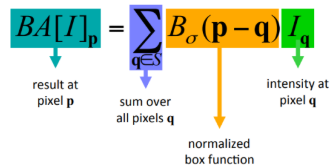

In [ ]:
def apply_box_filter(img, kernel_size=5):
    # OpenCV의 blur 함수는 normalized box filter를 수행합니다.
    return cv2.blur(img, (kernel_size, kernel_size))

# 1. 이미지 로드
pikachu_path = str(ROOT / '피카츄.png')
if os.path.exists(pikachu_path):
    img = cv2.imread(pikachu_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. 가우시안 노이즈 추가
h, w, c = img.shape
mean = 0
var = 0.1
sigma = var ** 0.5
gaussian = np.random.normal(mean, sigma, (h, w, c)) * 255
noisy_img = np.clip(img + gaussian, 0, 255).astype(np.uint8)

# 3. 박스 필터 적용
denoised_img = apply_box_filter(noisy_img, kernel_size=5)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(noisy_img); axes[1].set_title("Noisy (Gaussian)"); axes[1].axis("off")
axes[2].imshow(denoised_img); axes[2].set_title("Denoised (Box Filter)"); axes[2].axis("off")
plt.tight_layout()
plt.show()

## 10. Denoising: Gaussian Filter

Normalized Gaussian function을 사용하여 가중 평균을 구하는 방식입니다.

$$G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

이 필터는 Box 필터보다 이미지를 더 자연스럽게 블러링하며, 고주파 노이즈 제거에 효과적입니다.

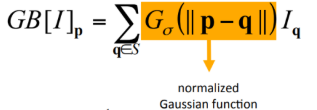

In [ ]:
def apply_gaussian_filter(img, kernel_size=5, sigma=1.0):
    # OpenCV의 GaussianBlur 함수를 사용하여 필터링을 적용합니다.
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), sigmaX=sigma)

# 가우시안 필터 적용
g_denoised_img = apply_gaussian_filter(noisy_img, kernel_size=5, sigma=1.5)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(noisy_img); axes[1].set_title("Noisy (Gaussian)"); axes[1].axis("off")
axes[2].imshow(denoised_img); axes[2].set_title("Denoised (Box Filter)"); axes[2].axis("off")
axes[3].imshow(g_denoised_img); axes[3].set_title("Denoised (Gaussian Filter)"); axes[3].axis("off")

plt.tight_layout()
plt.show()